This needs data available in ./parquet/*.parquet. If those files aren't available first run code in ./make_data.ipynb

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd

In [11]:
pq_path = "data/parquet/diseases-diseases_confidence_score.parquet"

pq_file = pq.ParquetFile(pq_path)

In [12]:
prop_name = pq_file.schema[5].name

In [ ]:
pq_path = "data/parquet/diseases-diseases_confidence_score.parquet"
pq_file = pq.ParquetFile(pq_path)
prop_name = pq_file.schema[5].name
arr = pq_file.read(columns=[prop_name])
series = arr.to_pandas()[prop_name]

In [14]:
series = arr.to_pandas()[prop_name]

In [17]:
type(series)

pandas.Series

NameError: name 'series' is not defined

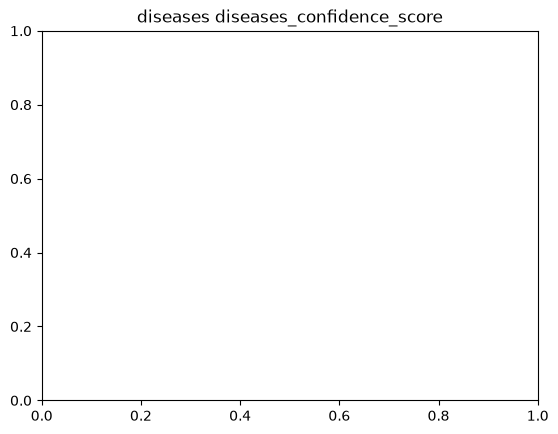

In [8]:
fname = "diseases-diseases_confidence_score.parquet"
fig, ax = plt.subplots()
ax.set_title(" ".join(fname.split(".")[0].split('-')))
ax.hist(series, bins=20,log=True)

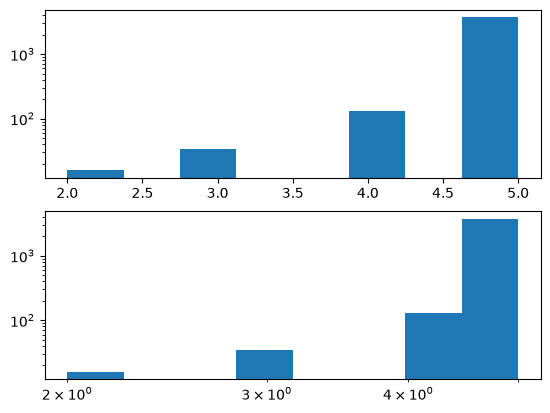

In [21]:
plt.subplot(211)
hist, bins, _ = plt.hist(arr, bins=8, log=True)

# histogram on log scale. 
# Use non-equal bin sizes, such that they look equal on log scale.
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))


plt.subplot(212)
plt.hist(arr, bins=logbins, log=True)
plt.xscale('log')
plt.show()

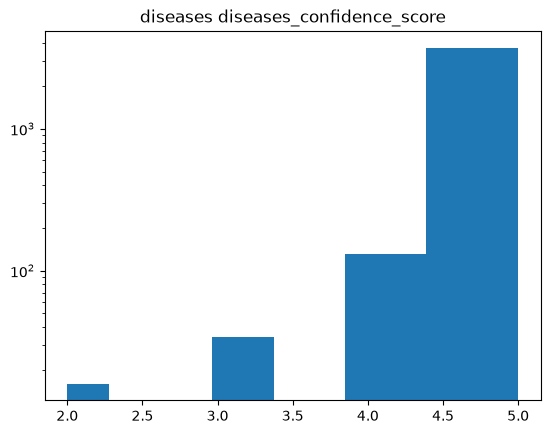

In [ ]:
def plotHistogram(prop_vals:pd.Series, bins, log_y:bool=False, chart_title=""):
    fig, ax = plt.subplots()
    ax.set_title(chart_title)
    ax.hist(prop_vals, bins=bins,log=log_y)

def handleInputAndData(pq_path,bin_cnt:int,log_bins:bool,log_y:bool):
    chart_title = " ".join(Path(pq_path).stem.split('-'))

    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    arr = pq_file.read(columns=[prop_name])
    prop_vals = arr.to_pandas()[prop_name]
    if(log_bins):
        bins = np.logspace(np.log10(prop_vals.min()),np.log10(prop_vals.max()),bin_cnt)
    else: #No need to take the bins to log space, just let matplot handle the splitting 
        bins = bin_cnt
    plotHistogram(prop_vals,bins,log_y,chart_title)
handleInputAndData(pq_path,8,True,True)

In [ ]:
for i,fname in enumerate(os.listdir("parquet")):
    if(fname.startswith("_")):continue
    dist = []
    with open("histogram_data/"+fname) as csvfile:
        reader = csv.reader((filter(lambda row: row[0]!='#',csvfile)))
        next(reader)
        for row in reader:dist.append(float(row[2]))
    fig, ax = plt.subplots()
    ax.set_title(" ".join(fname.split(".")[0].split('-')))
    ax.hist(dist, bins=n_bins,log=True)
#    dist = makePlt(fname,20)
    fig.savefig("histogram_data/histogram_pics/"+fname.split(".")[0]+".png")
#    print(dist)

In [2]:
from pathlib import Path

In [3]:
p = Path("data/parquet/diseases-diseases_confidence_score.parquet")

In [5]:
p.stem

'diseases-diseases_confidence_score'